# 095. Text Summation using Attention Model

- 전체 sentence 를 짧은 문장으로 요약  

- NLP 의 Text Summarization approach 2 가지  
    1. Extractive Summarization (추출 요약) - 원문에서 중요 문장/단어 추출
    2. Abstractive Summarization (추상 요약) - 원문으로부터 새로운 문장 생성 --> Deep Learning approach  
    
    
    
- Attention model 을 이용하여 긴 문장을 짧게 요약

In [1]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt
import re  
import time
import os
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
data=pd.read_csv("/content/drive/My Drive/amazon-fine-food-reviews/Reviews.csv",nrows=100000)

In [47]:
data.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."


## drop duplicate and na values

In [0]:
data.drop_duplicates(subset=['Text'], inplace=True)  #dropping duplicates
data.dropna(axis=0, inplace=True)   #dropping na

In [0]:
def preprocess_sentence(sent):
    cleaned_sentence = []
    for txt in sent:
        new_txt = re.sub(r'[^a-zA-Z ]', '', txt)
        new_txt = new_txt.lower()
        new_txt = new_txt.rstrip().strip()
        cleaned_sentence.append('<start> ' + new_txt + ' <end>')
    return cleaned_sentence

In [0]:
cleaned_text = preprocess_sentence(data['Text'])

In [10]:
cleaned_text[:3]

['<start> i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than  most <end>',
 '<start> product arrived labeled as jumbo salted peanutsthe peanuts were actually small sized unsalted not sure if this was an error or if the vendor intended to represent the product as jumbo <end>',
 '<start> this is a confection that has been around a few centuries  it is a light pillowy citrus gelatin with nuts  in this case filberts and it is cut into tiny squares and then liberally coated with powdered sugar  and it is a tiny mouthful of heaven  not too chewy and very flavorful  i highly recommend this yummy treat  if you are familiar with the story of cs lewis the lion the witch and the wardrobe  this is the treat that seduces edmund into selling out his brother and sisters to the witch <end>']

In [0]:
cleaned_summary = preprocess_sentence(data['Summary'])

In [12]:
cleaned_summary[:3]

['<start> good quality dog food <end>',
 '<start> not as advertised <end>',
 '<start> delight says it all <end>']

In [13]:
print(len(cleaned_text))
print(len(cleaned_summary))

88421
88421


cleaned_text 의 최대 길이 : 14868
cleaned_text 의 최소 길이 : 44
cleaned_text 의 평균 길이 : 437.43
cleaned_summary 의 최대 길이 : 139
cleaned_summary 의 최소 길이 : 14
cleaned_summary 의 평균 길이 : 36.58


Text(0.5, 1.0, 'Summary')

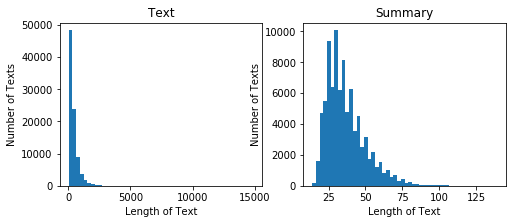

In [14]:
print(f"cleaned_text 의 최대 길이 : {max([len(txt) for txt in cleaned_text])}")
print(f"cleaned_text 의 최소 길이 : {min([len(txt) for txt in cleaned_text])}")
print(f"cleaned_text 의 평균 길이 : {np.mean([len(txt) for txt in cleaned_text]):.2f}")
print(f"cleaned_summary 의 최대 길이 : {max([len(txt) for txt in cleaned_summary])}")
print(f"cleaned_summary 의 최소 길이 : {min([len(txt) for txt in cleaned_summary])}")
print(f"cleaned_summary 의 평균 길이 : {np.mean([len(txt) for txt in cleaned_summary]):.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.hist([len(txt) for txt in cleaned_text], bins=50)
ax1.set_xlabel("Length of Text")
ax1.set_ylabel("Number of Texts")
ax1.set_title("Text")

ax2.hist([len(txt) for txt in cleaned_summary], bins=50)
ax2.set_xlabel("Length of Text")
ax2.set_ylabel("Number of Texts")
ax2.set_title("Summary")

In [0]:
# Calculate max_length of the target tensors
max_length_text = 100
max_length_summary = 20

In [0]:
def max_length(tensor):
    return max(len(t) for t in tensor)

def tokenize(data, max_length):
    lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
    
    lang_tokenizer.fit_on_texts(data)

    tensor = lang_tokenizer.texts_to_sequences(data)

    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, maxlen=max_length, padding='post')

    return tensor, lang_tokenizer

In [0]:
text_tensor, text_tokenizer = tokenize(cleaned_text, max_length_text)
summary_tensor, summary_tokenizer = tokenize(cleaned_summary, max_length_summary)

In [18]:
max_length(text_tensor), max_length(summary_tensor)

(100, 20)

In [19]:
# Creating training and validation sets using an 80-20 split
input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val \
                                        = train_test_split(text_tensor, summary_tensor, test_size=0.2)

# Show length
print(len(input_tensor_train), len(target_tensor_train))
print(len(input_tensor_val), len(target_tensor_val))

70736 70736
17685 17685


In [0]:
BUFFER_SIZE = 10000   
BATCH_SIZE = 64
steps_per_epoch = 500    #len(input_tensor_train)//BATCH_SIZE    
embedding_dim = 256
units = 1024
vocab_inp_size = len(text_tokenizer.word_index) + 1       
vocab_tar_size = len(summary_tokenizer.word_index) + 1      

dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

In [21]:
example_input_batch, example_target_batch = next(iter(dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([64, 100]), TensorShape([64, 20]))

In [0]:
class Encoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
    super(Encoder, self).__init__()
    self.batch_sz = batch_sz
    self.enc_units = enc_units
    
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    
    self.gru = tf.keras.layers.GRU(self.enc_units,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform')

  def call(self, x, hidden):
    x = self.embedding(x)
    output, state = self.gru(x, initial_state = hidden)
    return output, state

  def initialize_hidden_state(self):
    return tf.zeros((self.batch_sz, self.enc_units))

In [23]:
encoder = Encoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE)

# sample input
sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)
print ('Encoder output shape: (batch size, max input sequence length, units) {}'
                       .format(sample_output.shape))
print ('Encoder Hidden state shape: (batch size, units) {}'.format(sample_hidden.shape))

Encoder output shape: (batch size, max input sequence length, units) (64, 100, 1024)
Encoder Hidden state shape: (batch size, units) (64, 1024)


In [0]:
class BahdanauAttention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W1 = tf.keras.layers.Dense(units)
    self.W2 = tf.keras.layers.Dense(units)
    self.V = tf.keras.layers.Dense(1)

  def call(self, query, values):
    
    # score shape == (batch_size, max_length, 1) -> (64, 16, 1)  
    # we get 1 at the last axis because we are applying score to self.V
    hidden_with_time_axis = tf.expand_dims(query, 1)
    score = self.V(tf.nn.tanh(self.W1(values) + self.W2(hidden_with_time_axis)))

    # attention_weights shape == (batch_size, input_lang_max_length, 1) -> (64, 16, 1)
    attention_weights = tf.nn.softmax(score, axis=1)

    # context_vector(어텐션 값) shape after sum == (batch_size, hidden_size)
    context_vector = attention_weights * values
    context_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights

In [25]:
attention_layer = BahdanauAttention(10)
attention_result, attention_weights = attention_layer(sample_hidden, sample_output)

print("Attention result shape: (batch size, hidden_units) {}".format(attention_result.shape))
print("Attention weights shape: (batch_size, input_lang_max_sequence_length, 1) {}"
                  .format(attention_weights.shape))

Attention result shape: (batch size, hidden_units) (64, 1024)
Attention weights shape: (batch_size, input_lang_max_sequence_length, 1) (64, 100, 1)


In [0]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
    super(Decoder, self).__init__()
    self.batch_sz = batch_sz
    self.dec_units = dec_units
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(self.dec_units,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform')
    self.fc = tf.keras.layers.Dense(vocab_size)     # vocab_size - target_lang vocab_size (4935)

    # used for attention
    self.attention = BahdanauAttention(self.dec_units)        

  def call(self, x, hidden, enc_output):
    
    # context_vector (batch_size, hidden_size) -> (64, 1024)
    # attention_weights (64, 16, 1)
    context_vector, attention_weights = self.attention(hidden, enc_output)

    # x shape after passing through embedding == (batch_size, 1, embedding_dim)
    # (64, 1, 256)
    x = self.embedding(x)

    # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
    # attention 값 (context vector) 과 timestep t 의 output 을 연결
    x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

    # passing the concatenated vector to the GRU
    output, state = self.gru(x)

    # output shape == (batch_size * 1, hidden_size)
    output = tf.reshape(output, (-1, output.shape[2]))

    # output shape == (batch_size, vocab) -> (64, 4935)
    x = self.fc(output)

    return x, state, attention_weights

In [27]:
decoder = Decoder(vocab_tar_size, embedding_dim, units, BATCH_SIZE)

sample_decoder_output, _, _ = decoder(tf.random.uniform((BATCH_SIZE, 1)),
                                      sample_hidden, sample_output)

print ('Decoder output shape: (batch_size, target_lang_vocab size) {}'
                       .format(sample_decoder_output.shape))

Decoder output shape: (batch_size, target_lang_vocab size) (64, 17096)


In [0]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
                    from_logits=True, reduction='none')

def loss_function(real, pred):     

  # batch 64 개 record 중 timestep t 에 0 padding 이 아닌 
  # 실제 단어가 존재하는 record 만 True 로 만듦
  mask = tf.math.logical_not(tf.math.equal(real, 0))    

  # [word_index] 에 대한 확률분포 array - (64, ), dtype=float32 
  loss_ = loss_object(real, pred)    

  # mask dtype 을 float32 로 type cast
  mask = tf.cast(mask, dtype=loss_.dtype)   

  loss_ *= mask             # 실제 단어가 존재하는 위치 외에는 모두 0 으로 만든다

  return tf.reduce_mean(loss_) 

In [0]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [0]:
@tf.function
def train_step(inp, targ, enc_hidden):
  loss = 0

  with tf.GradientTape() as tape:
    enc_output, enc_hidden = encoder(inp, enc_hidden)
    
    # decoder hidden state 의 초기값은  encoder  last hidden state
    dec_hidden = enc_hidden   

    # dec_input shape (batch_size, 1) 
    dec_input = tf.expand_dims([summary_tokenizer.word_index['<start>']] * BATCH_SIZE, 1)

    # Teacher forcing - feeding the target as the next input
    for t in range(1, targ.shape[1]):    
      # passing enc_output to the decoder
      predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)

      loss += loss_function(targ[:, t], predictions)  

      # using teacher forcing - predictions 가 아닌 true value 를 
      # next step 의 dec_input 으로 제공
      dec_input = tf.expand_dims(targ[:, t], 1)

  batch_loss = (loss / int(targ.shape[1]))

  variables = encoder.trainable_variables + decoder.trainable_variables

  gradients = tape.gradient(loss, variables)

  optimizer.apply_gradients(zip(gradients, variables))

  return batch_loss

In [31]:
EPOCHS = 10

for epoch in range(EPOCHS):
  start = time.time()

  enc_hidden = encoder.initialize_hidden_state()
  total_loss = 0

  for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):

    batch_loss = train_step(inp, targ, enc_hidden)
    total_loss += batch_loss

    if batch % 100 == 0:
      print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1,
                                                   batch,
                                                   batch_loss.numpy()))
  # saving (checkpoint) the model every 2 epochs
  if (epoch + 1) % 2 == 0:
    checkpoint.save(file_prefix = checkpoint_prefix)

  print('Epoch {} 평균 Loss {:.4f}'.format(epoch + 1, total_loss / steps_per_epoch))
  print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

Epoch 1 Batch 0 Loss 2.3606
Epoch 1 Batch 100 Loss 1.5405
Epoch 1 Batch 200 Loss 1.7334
Epoch 1 Batch 300 Loss 1.3417
Epoch 1 Batch 400 Loss 1.4127
Epoch 1 평균 Loss 1.4710
Time taken for 1 epoch 558.3278503417969 sec

Epoch 2 Batch 0 Loss 1.2272
Epoch 2 Batch 100 Loss 1.4373
Epoch 2 Batch 200 Loss 1.3578
Epoch 2 Batch 300 Loss 1.1948
Epoch 2 Batch 400 Loss 1.1724
Epoch 2 평균 Loss 1.3477
Time taken for 1 epoch 534.5744423866272 sec

Epoch 3 Batch 0 Loss 1.2034
Epoch 3 Batch 100 Loss 1.1234
Epoch 3 Batch 200 Loss 1.1648
Epoch 3 Batch 300 Loss 1.3049
Epoch 3 Batch 400 Loss 1.2907
Epoch 3 평균 Loss 1.2763
Time taken for 1 epoch 532.6050865650177 sec

Epoch 4 Batch 0 Loss 1.3367
Epoch 4 Batch 100 Loss 1.1137
Epoch 4 Batch 200 Loss 1.1986
Epoch 4 Batch 300 Loss 1.2915
Epoch 4 Batch 400 Loss 1.1258
Epoch 4 평균 Loss 1.2077
Time taken for 1 epoch 536.0973165035248 sec

Epoch 5 Batch 0 Loss 1.1572
Epoch 5 Batch 100 Loss 1.0603
Epoch 5 Batch 200 Loss 1.0665
Epoch 5 Batch 300 Loss 1.1247
Epoch 5 Batch 

In [0]:
def evaluate(sentence):

  sentence = preprocess_sentence(sentence)[0]

  print(sentence)
  inputs = [text_tokenizer.word_index.get(i, 0) for i in sentence.split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                         maxlen=max_length_text,
                                                         padding='post')
  print(inputs)
  inputs = tf.convert_to_tensor(inputs)

  result = ''

  hidden= [tf.zeros((1, units))]   # units : 1024
  enc_out, enc_hidden = encoder(inputs, hidden)

  dec_hidden = enc_hidden
  dec_input = tf.expand_dims([summary_tokenizer.word_index['<start>']], 0)

  for t in range(max_length_summary):      
    predictions, dec_hidden, attention_weights  \
            = decoder(dec_input, dec_hidden, enc_out)
    # storing the attention weights to plot later on
    attention_weights = tf.reshape(attention_weights, (-1, ))

    predicted_id = tf.argmax(predictions[0]).numpy()

    result += summary_tokenizer.index_word[predicted_id] + ' '

    if summary_tokenizer.index_word[predicted_id] == '<end>':
      return result, sentence

    # the predicted ID is fed back into the model - no teacher-forcing
    dec_input = tf.expand_dims([predicted_id], 0)

  return result, sentence

In [0]:
def translate(sentence):
  print(sentence)
  result, sentence = evaluate(sentence)

  print('Input: %s' % (sentence))
  print('Predicted translation: {}'.format(result))

In [39]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [49]:
translate(['i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than  most'])

['i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than  most']
<start> i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than  most <end>
[[  10    2   19  124  321    7    1 6513  517   95   59  209    3   19
   117   30   42    5   32    7   31  187    1   43  578   49   27    4
  2915   58    4 1146  451    3    6  651  101   14 5457    8 1883    3
   106 7996    9   43  101   58    0  139   11    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0  